# Sentinela Verde — o classificador funcionando

**Como o modelo enxerga o território**, com imagem de satélite de verdade.

Os outros notebooks mostram *resultado* — tabelas, testes, p-valores. Este mostra o **instrumento**.
A ideia é simples: antes de discutir se o efeito existe, ver o que o modelo faz com uma cena.

> Tem uma célula interativa no fim: `mostrar("site", ano)` renderiza qualquer site e ano na hora,
> direto dos rasters. Não é figura pré-assada — dá para trocar e rodar.

## Setup

In [1]:
from pathlib import Path
import sys

def _raiz(p: Path) -> Path:
    for c in [p.resolve(), *p.resolve().parents]:
        if (c / "pyproject.toml").exists():
            return c
    raise RuntimeError("raiz não encontrada")

REPO = _raiz(Path.cwd())
sys.path.insert(0, str(REPO / "modelo-impacto-score" / "scripts"))
sys.path.insert(0, str(REPO / "dados-modelo-impacto" / "scripts"))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

DEMO = REPO / "modelo-impacto-score" / "reports" / "figuras" / "demo"
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 40, "display.width", 200)
print("pronto")

pronto


---
## 1. O problema, em uma imagem

Um satélite não entrega "área construída". Entrega **reflectância** — quanta luz cada pedaço de
chão devolveu, em seis faixas do espectro. O trabalho do classificador é traduzir isso em algo que
uma pessoa consegue interpretar.

Os três painéis abaixo são **a mesma cena, no mesmo instante**:

1. **Cor verdadeira** — o que o olho veria do espaço. Bonito, e quase inútil para medir: telhado,
   solo seco e asfalto viram tons parecidos de cinza.
2. **Falsa-cor** — troca-se o vermelho pelo infravermelho próximo. Vegetação viva reflete muito
   infravermelho e vira **vermelho vivo**. De repente a diferença entre mato e concreto salta.
3. **A classificação** — cada pixel colocado em uma das 5 classes do projeto.

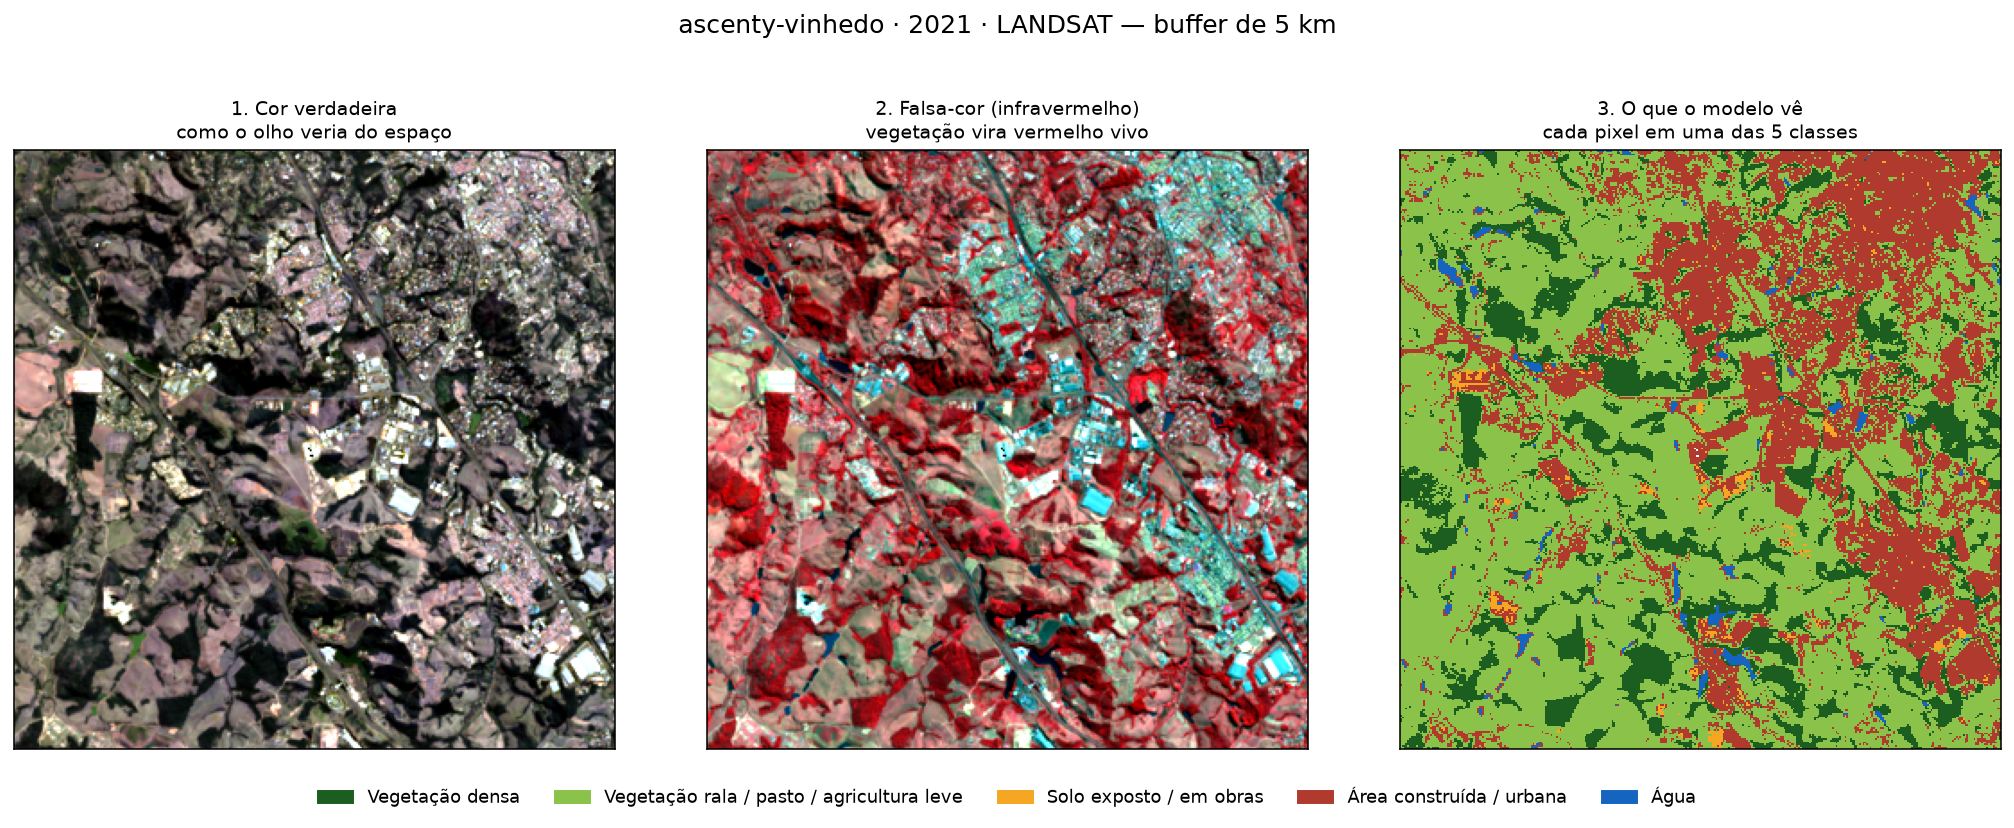

In [2]:
display(Image(filename=str(DEMO / "demo_lado_a_lado_ascenty-vinhedo_2021.png")))

As 5 classes foram fechadas pelo time no início do projeto (`docs/classes.md`):

| classe | o que é | por que existe |
|---|---|---|
| 🟩 **Vegetação densa** | mata, floresta | linha de base ambiental |
| 🟨 **Vegetação rala** | pasto, agricultura leve | o que mais vira obra no Brasil |
| 🟧 **Solo exposto / em obras** | terra nua, canteiro | **a classe crítica** — sinal de construção começando |
| 🟥 **Área construída** | edificação, asfalto | o destino da conversão |
| 🟦 **Água** | rio, represa | controle ambiental |

**Sobre a classe laranja, com honestidade:** ela é a **pior** do modelo (F1 0,579, contra 0,74–0,92
das outras). O motivo não é o algoritmo — é que a fonte de rótulos (MapBiomas) **não tem** classe
"canteiro de obras", então treinamos com um proxy de solo nu natural. Está documentado em
`ADR-004`, e é justamente o que o `ADR-006` propõe consertar.

---
## 2. A mesma área, ano após ano

É aqui que o instrumento vira série temporal. Cada quadro é um ano, classificado
independentemente, sempre com composto da estação seca para reduzir nuvem.

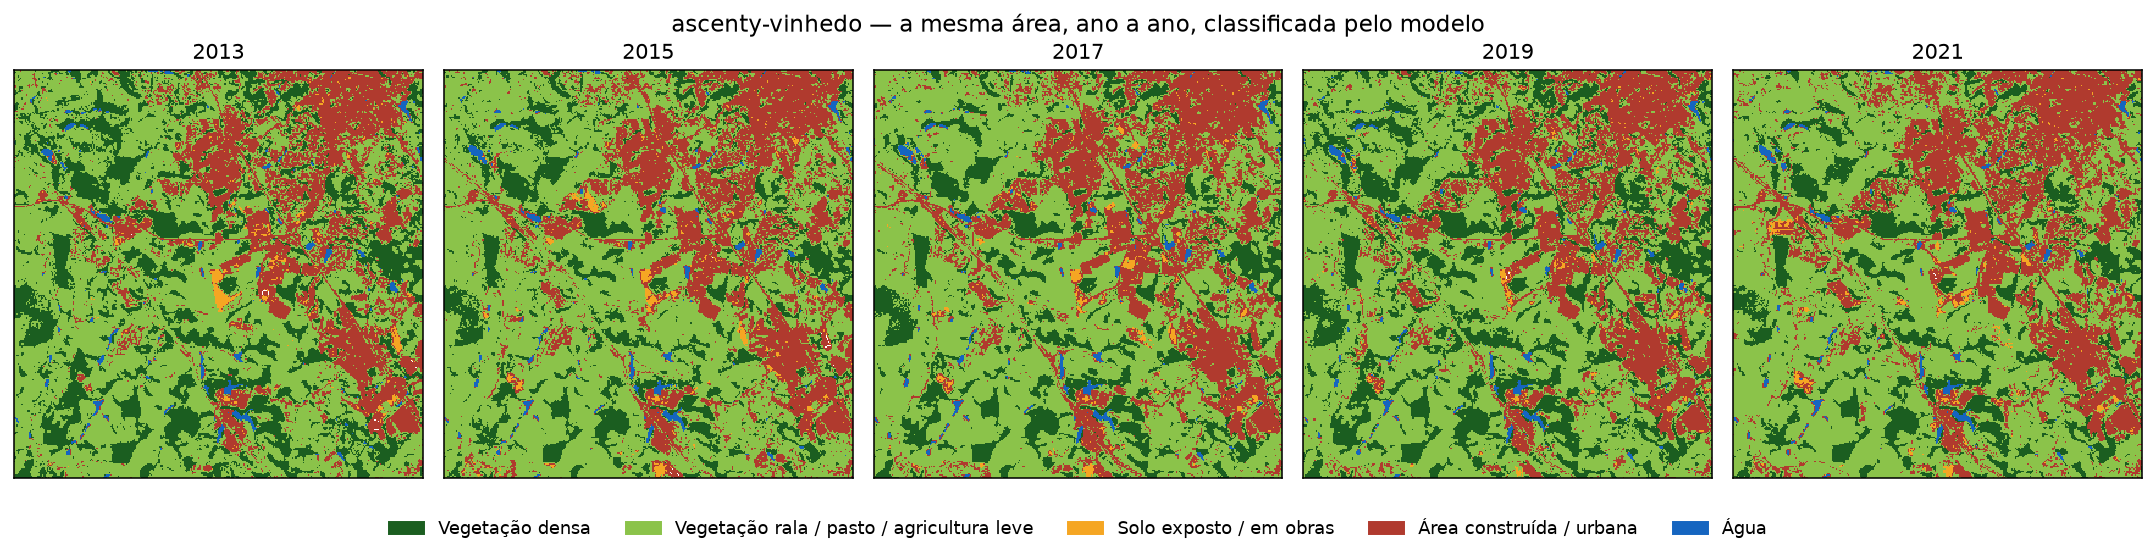

In [3]:
display(Image(filename=str(DEMO / "demo_serie_ascenty-vinhedo.png")))

### O caso mais visual do estudo: ClickIP Manaus

Dos 15 campi, este é o **único** cujo terreno tinha **0% de área construída** antes da obra. Nos
outros, metade do terreno (mediana) já era construída — são data centers erguidos dentro de
parques industriais que já existiam.

Aqui não. E o classificador vê: **75% dos pixels do footprint viraram construída**.

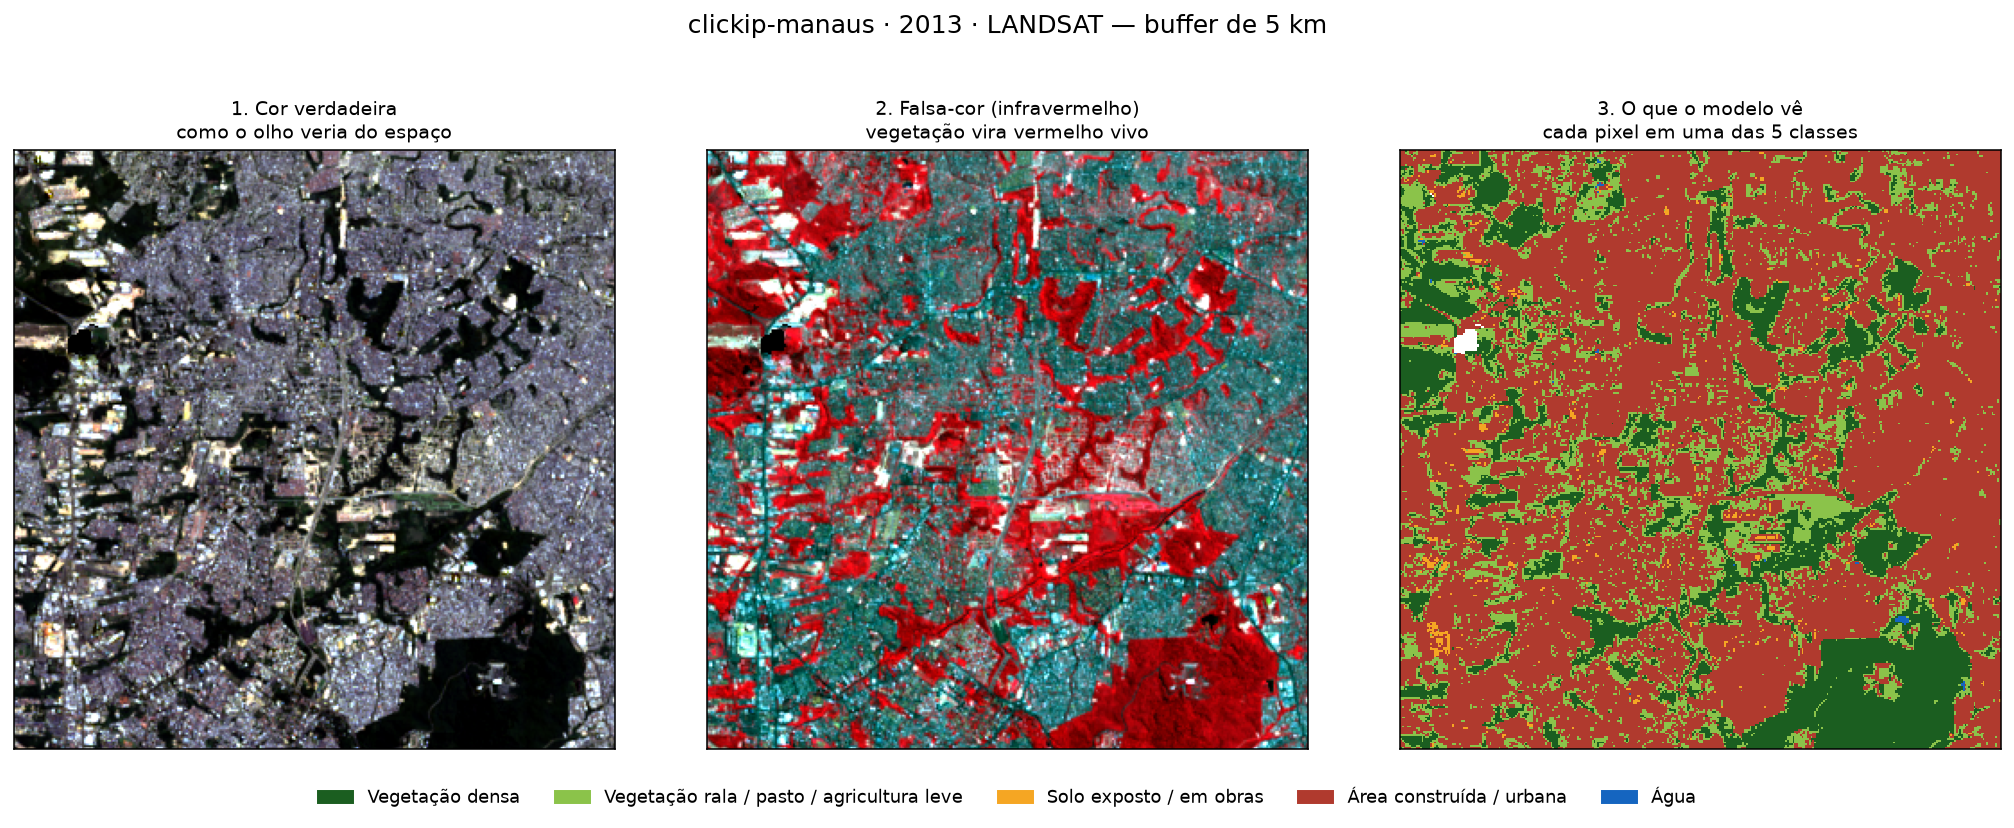

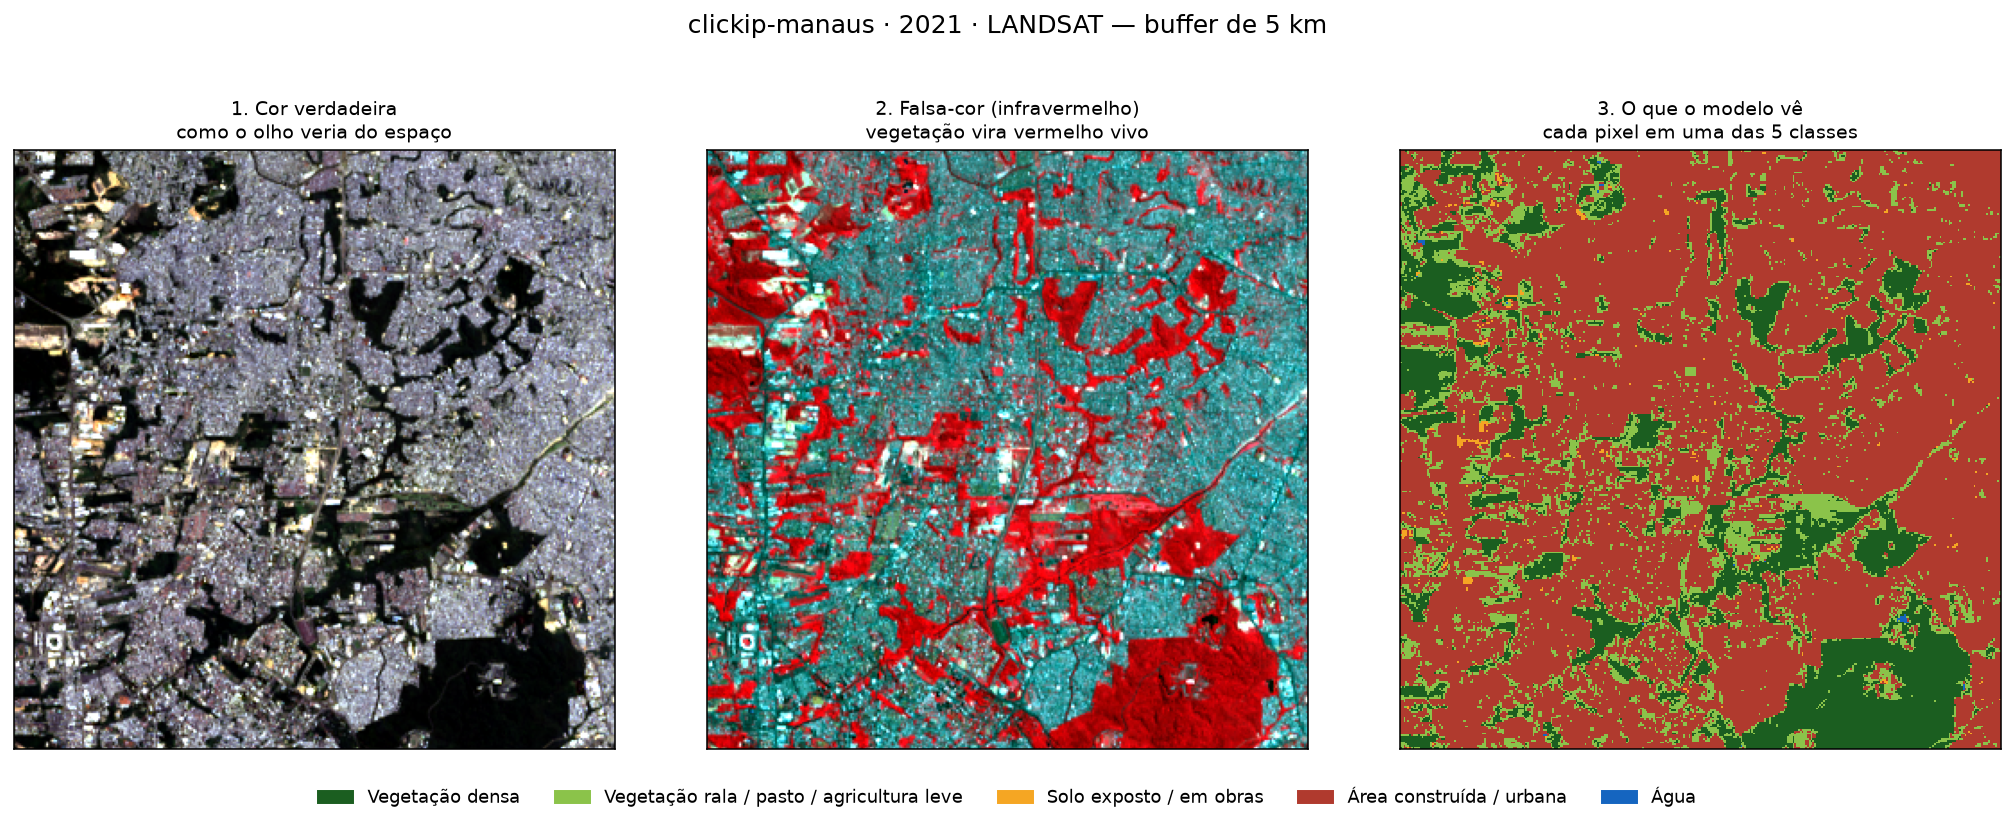

In [4]:
display(Image(filename=str(DEMO / "demo_lado_a_lado_clickip-manaus_2013.png")))
display(Image(filename=str(DEMO / "demo_lado_a_lado_clickip-manaus_2021.png")))

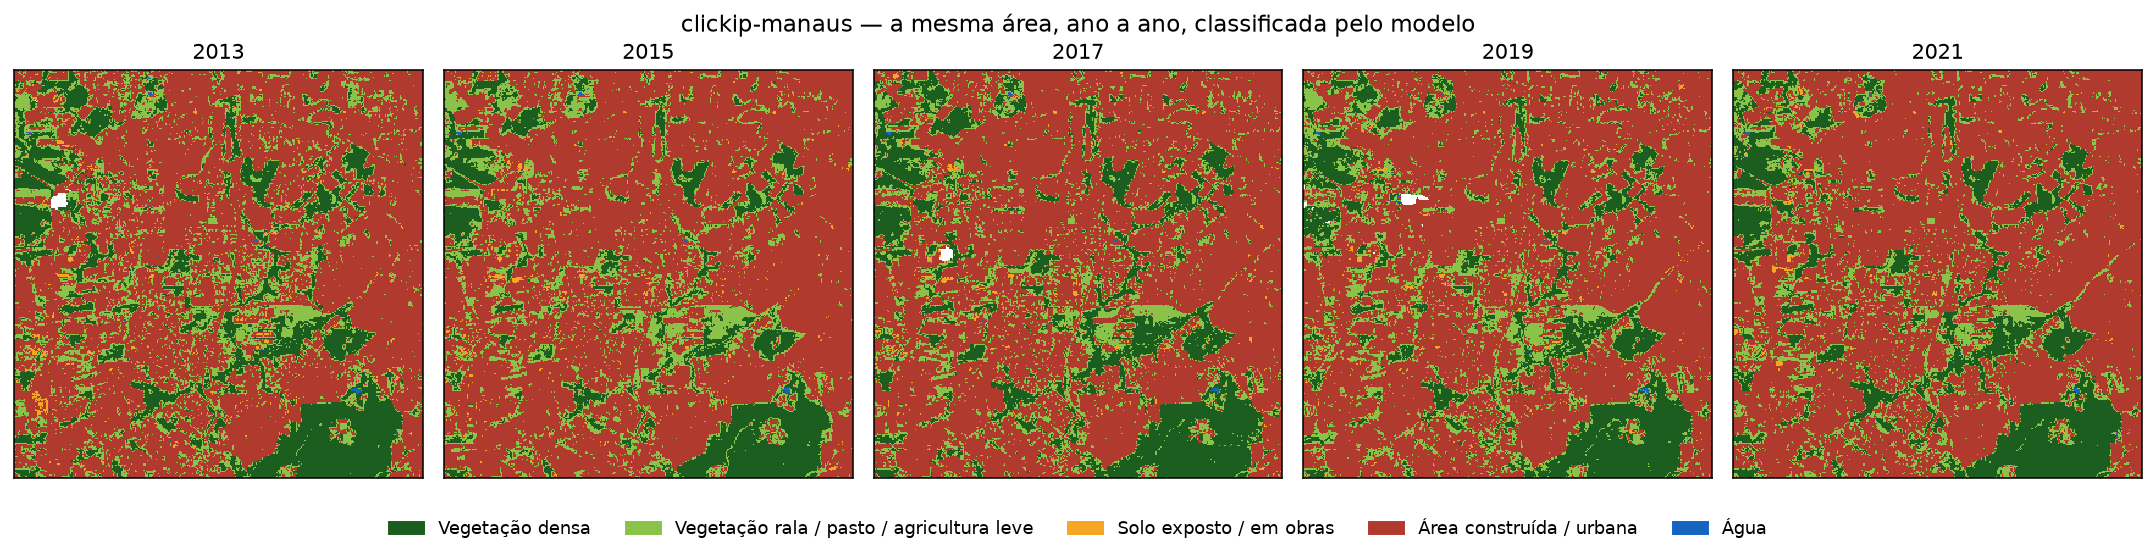

In [5]:
display(Image(filename=str(DEMO / "demo_serie_clickip-manaus.png")))

---
## 3. Onde o modelo tem dúvida — e por que isso importa

Um classificador que só devolve a classe esconde o mais interessante: **o quanto ele acredita** na
própria resposta. O modelo publica isso pixel a pixel.

No painel da direita, **vermelho = o modelo está em dúvida**. Repare onde a dúvida se concentra:
nas **bordas** entre classes, que é exatamente onde o pixel de 30 m mistura dois tipos de chão.

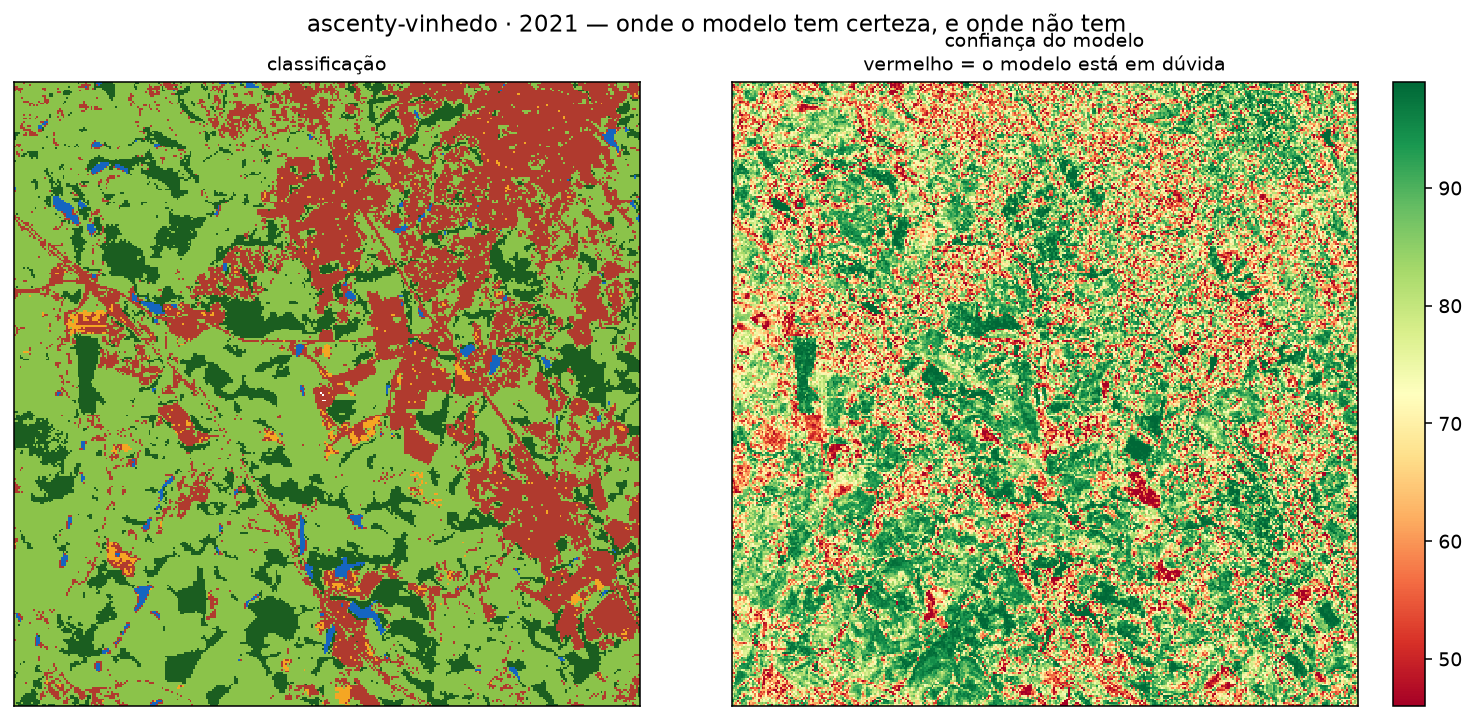

In [6]:
display(Image(filename=str(DEMO / "demo_confianca_ascenty-vinhedo_2021.png")))

---
## 4. Onde o impacto é medido

O achado do projeto não é sobre a imagem inteira — é sobre **anéis concêntricos** ao redor do data
center. Os círculos abaixo são exatamente as zonas de medição.

O efeito vive no anel branco (500 m), cai pela metade no amarelo (1 km) e **desaparece** no azul
(2 km). E o prédio do próprio data center é **excluído** da conta — senão a leitura seria circular.

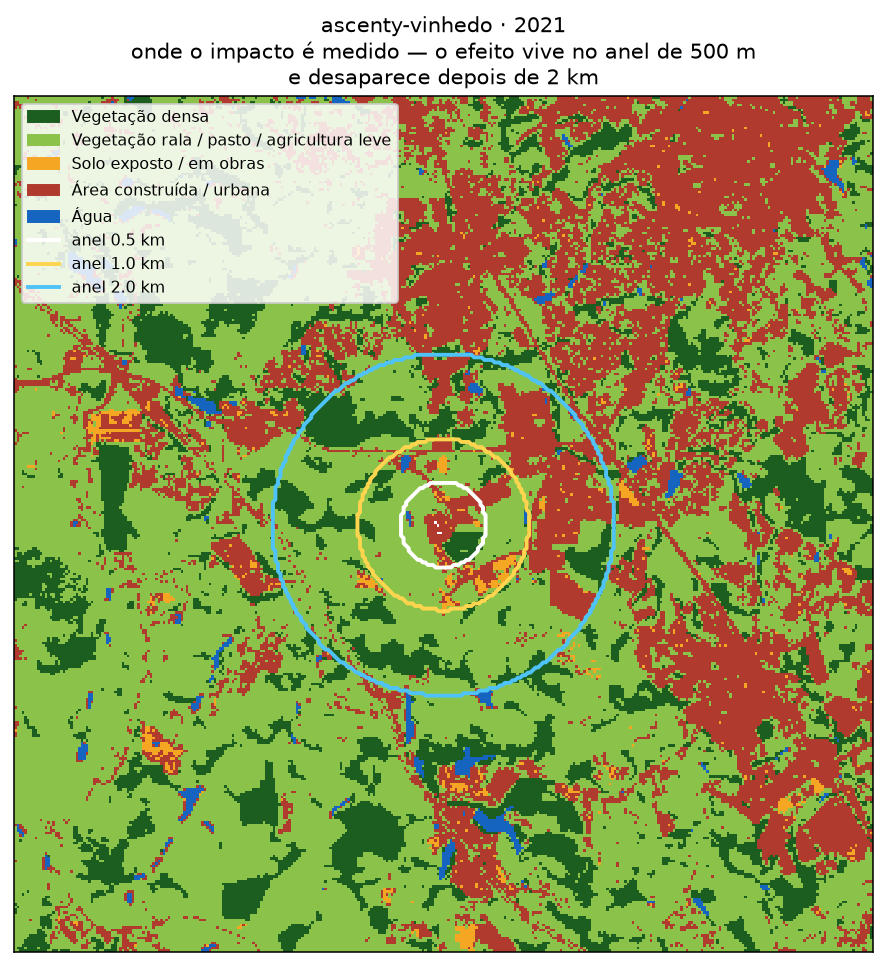

In [7]:
display(Image(filename=str(DEMO / "demo_aneis_ascenty-vinhedo_2021.png")))

---
## 5. O que o classificador acerta, e o que não acerta

In [8]:
sel = pd.read_csv(REPO / "modelo-impacto-score" / "outputs" / "selos_de_evidencia.csv")
print("Desempenho por classe (rf_v1.0-tuned, holdout espacial):\n")
print(f"  {'classe':28s} {'F1':>6s}")
for nome, f1 in [("Vegetação densa", 0.92), ("Área construída", 0.88),
                 ("Água", 0.86), ("Vegetação rala", 0.74),
                 ("Solo exposto / em obras", 0.579)]:
    marca = "   <- a classe crítica, e a pior" if f1 < 0.6 else ""
    print(f"  {nome:28s} {f1:6.2f}{marca}")
print("\nFonte: reports/avaliacao_rf_v1.0-tuned.md")

Desempenho por classe (rf_v1.0-tuned, holdout espacial):

  classe                           F1
  Vegetação densa                0.92
  Área construída                0.88
  Água                           0.86
  Vegetação rala                 0.74
  Solo exposto / em obras        0.58   <- a classe crítica, e a pior

Fonte: reports/avaliacao_rf_v1.0-tuned.md


### A pergunta que um avaliador faria: "se a classe crítica é ruim, o resultado vale?"

**Vale, e há uma razão específica.** O achado principal usa a assinatura `virou_construida`, que é
baseada na **classe 4** (área construída, F1 0,88). A classe 3 fraca só aparece numa variante
secundária. **A classe ruim não sustenta o resultado principal.**

E há uma segunda defesa, que é mais forte: o **teste placebo**. Aplicamos o método idêntico — com
esse mesmo classificador e todos os seus defeitos — a 15 pares de lugares onde **nenhum** data
center foi construído.

In [9]:
RES = REPO / "dados-modelo-impacto" / "raw" / "controles-rf"
pl = pd.read_csv(RES / "placebo_resumo.csv")
pl = pl[pl.assinatura == "virou_construida"]
for _, r in pl.iterrows():
    print(f"{r.raio_km:>4.1f} km   PLACEBO {int(r.placebo_n_positivo):2d}/{int(r.placebo_n_pares)}"
          f"  p={r.placebo_p_unilateral:.3f}      "
          f"REAL {r.real_frac_positivo:.0%}  p={r.real_p_unilateral:.4f}")
print("\nO placebo cai no acaso. Um classificador imperfeito não fabrica diferença")
print("entre dois lugares parecidos — e é isso que o teste mostra.")

 0.5 km   PLACEBO  8/15  p=0.500      REAL 87%  p=0.0037
 1.0 km   PLACEBO  7/15  p=0.696      REAL 87%  p=0.0037
 2.0 km   PLACEBO  7/15  p=0.696      REAL 60%  p=0.3036

O placebo cai no acaso. Um classificador imperfeito não fabrica diferença
entre dois lugares parecidos — e é isso que o teste mostra.


---
## 6. Interativo — troque e rode

A célula abaixo renderiza **qualquer** site e ano que estejam em disco, na hora, a partir dos
rasters. Troque os argumentos e execute de novo.

In [10]:
import importlib
import importlib.util

spec = importlib.util.spec_from_file_location(
    "_demo", REPO / "modelo-impacto-score" / "scripts" / "06_figuras_demo_visual.py")
_demo = importlib.util.module_from_spec(spec)
spec.loader.exec_module(_demo)

import numpy as np
import matplotlib.patches as mpatches

cmap, cores, nomes = _demo.paleta()

def mostrar(site: str, ano: int, sensor: str = "landsat"):
    """Imagem crua + classificação de um site/ano, direto do raster."""
    raw = _demo._ler(_demo.caminho_raw(sensor, site, ano))
    cls = _demo._ler(_demo.caminho_class(sensor, site, ano))
    if raw is None or cls is None:
        print(f"sem raster para {site}/{ano}/{sensor}")
        return
    fig, ax = plt.subplots(1, 2, figsize=(11, 5.2))
    ax[0].imshow(_demo.composicao(raw, (2, 1, 0)))
    ax[0].set_title(f"{site} · {ano} — imagem", fontsize=10)
    c = cls[0]
    ax[1].imshow(np.ma.masked_where(c == 0, c), cmap=cmap, vmin=0,
                 vmax=len(cmap.colors) - 1, interpolation="nearest")
    ax[1].set_title("classificação", fontsize=10)
    for a in ax:
        a.set_xticks([]); a.set_yticks([])
    h = [mpatches.Patch(color=cores[k], label=nomes[k]) for k in sorted(nomes) if k > 0]
    fig.legend(handles=h, loc="lower center", ncol=5, frameon=False, fontsize=8)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    plt.show()

# >>> TROQUE AQUI
mostrar("ascenty-hortolandia", 2018)

C:\Users\gabri\AppData\Local\Temp\ipykernel_24996\3814188717.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [11]:
# quais sites e anos existem em disco?
base = REPO / "data" / "processed" / "classificado" / "landsat"
disp = sorted(p.name for p in base.iterdir() if p.is_dir() and not p.name.startswith("ctrl"))
print(f"{len(disp)} sites com série Landsat:\n")
for s in disp:
    anos = sorted(int(f.stem) for f in (base / s).glob("*.tif") if "confianca" not in f.stem)
    print(f"  {s:28s} {anos[0]}-{anos[-1]}  ({len(anos)} anos)")

16 sites com série Landsat:

  angonap-fortaleza            2013-2023  (11 anos)
  ascenty-hortolandia          2013-2024  (12 anos)
  ascenty-jundiai              2013-2024  (12 anos)
  ascenty-maracanau            2013-2021  (9 anos)
  ascenty-osasco               2013-2024  (12 anos)
  ascenty-paulinia             2013-2024  (12 anos)
  ascenty-sumare               2013-2023  (11 anos)
  ascenty-vinhedo              2013-2024  (12 anos)
  clickip-manaus               2013-2021  (9 anos)
  equinix-santana-parnaiba     2013-2024  (12 anos)
  everest-goiania              2013-2024  (12 anos)
  hostdime-joao-pessoa         2013-2023  (11 anos)
  odata-hortolandia            2013-2021  (9 anos)
  scala-sgigsm01               2013-2021  (9 anos)
  scala-spoapa01               2013-2021  (9 anos)
  scala-tambore                2013-2024  (12 anos)


---
## 7. Onde continuar

| notebook | o quê |
|---|---|
| `01_modelo_impacto.ipynb` | o desenho de pareamento tratamento/controle, passo a passo |
| `02_impacto_score.ipynb` | o modelo de impacto: o que foi medido e o que não é predizível |
| `03_status_e_proximos_passos.ipynb` | onde estamos e o que vem depois |

Documentos: `modelo-impacto-score/reports/sumario-executivo.md` (1 página, sem p-valores) e
`relatorio-impacto.md` (técnico, com todas as limitações).

Reprodução completa: `python scripts/reproduzir_impacto.py --etapa completo`